## Import libraries

In [1]:
import tomopy
from helperFunctions import MoviePlotter
from tomoDataClass import tomoData
from alignment_methods import reprojection_consistency_score
import h5py
import numpy as np
from skimage.transform import pyramid_gaussian

In [2]:
def tomo_data(file,redo_align=False):
    try:
        with h5py.File(file) as hf:
            projs = hf['data'][...]
            angles = hf['angles'][...]
    except KeyError:
        with h5py.File(file) as hf:
            projs = hf['data'][...]
            angles = hf['angles'][...]
    angles = angles * np.pi / 180
    return projs, angles

## Import real Data

In [3]:
# Set projection angles
filename = "/Users/levihancock/Library/CloudStorage/Box-Box/BYU_CXI_Research_Team/ProjectFolders/IFE-STAR/IFE-Ptycho-Tomo/APS_2ID_GUP1013052_August_2025/levi_tomoReconstructions/tomo_data_run_final_2.hdf5"
# filename = "/home/ljh79/groups/grp_ptychi/nobackup/autodelete/Oct2025APSdata/tomo_data_run_final_2.hdf5"

projections_og, angles = tomo_data(filename, redo_align=True)
print(projections_og.shape)

num_angles, y_size, x_size = projections_og.shape


(558, 585, 1810)


In [4]:

from scipy.ndimage import zoom

# #downsample projections
downsample = 4
print(projections_og.shape)
projections = zoom(projections_og, (1, 1/downsample, 1/downsample), order=1)
print(projections.shape)
# projections = projections_og[::2,::4,::4]
# angles = angles[::2]
# print("Angles:", angles)
# print(projections.shape)

# print("Projections through object")
# MoviePlotter(projections)

# projections = projections_og
tomo = tomoData(projections, angles)

(558, 585, 1810)
(558, 146, 452)


In [5]:
print(projections.shape)
tomo.makeNotebookProjMovie()

(558, 146, 452)


Output()

## Align Data

In [6]:
# Show bad reconstruction prior to alignment
tomo.reset_workingProjections(x_size=None, y_size=None) #You can adjust these for tighter cropping
tomo.normalize(isPhaseData=True)

tomo.reconstruct(algorithm='art')
print("\nBad reconstruction prior to alignment")
badRecon = tomo.recon.copy()
MoviePlotter(badRecon)# 



Normalizing projections


Using CPU-based reconstruction. Algorithm:  art
Reconstruction completed.

Bad reconstruction prior to alignment


Output()



Computing reprojections of reconstruction...
Computing per-angle NRMSE...


NRMSE per angle: 100%|██████████| 558/558 [00:03<00:00, 164.57it/s]



─── Reprojection Consistency Score ───────────────────────
  RCS (mean NRMSE):   0.6185
  Best  angle [ 557]:  NRMSE = 0.1055
  Worst angle [ 461]:  NRMSE = 1.7094
  Std across angles:  0.2554
  Verdict:  ✗  Poor — significant misalignment or reconstruction failure.
───────────────────────────────────────────────────────────



/Users/levihancock/Documents/Work/Code/TomoMono/alignment_methods.py:1188: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


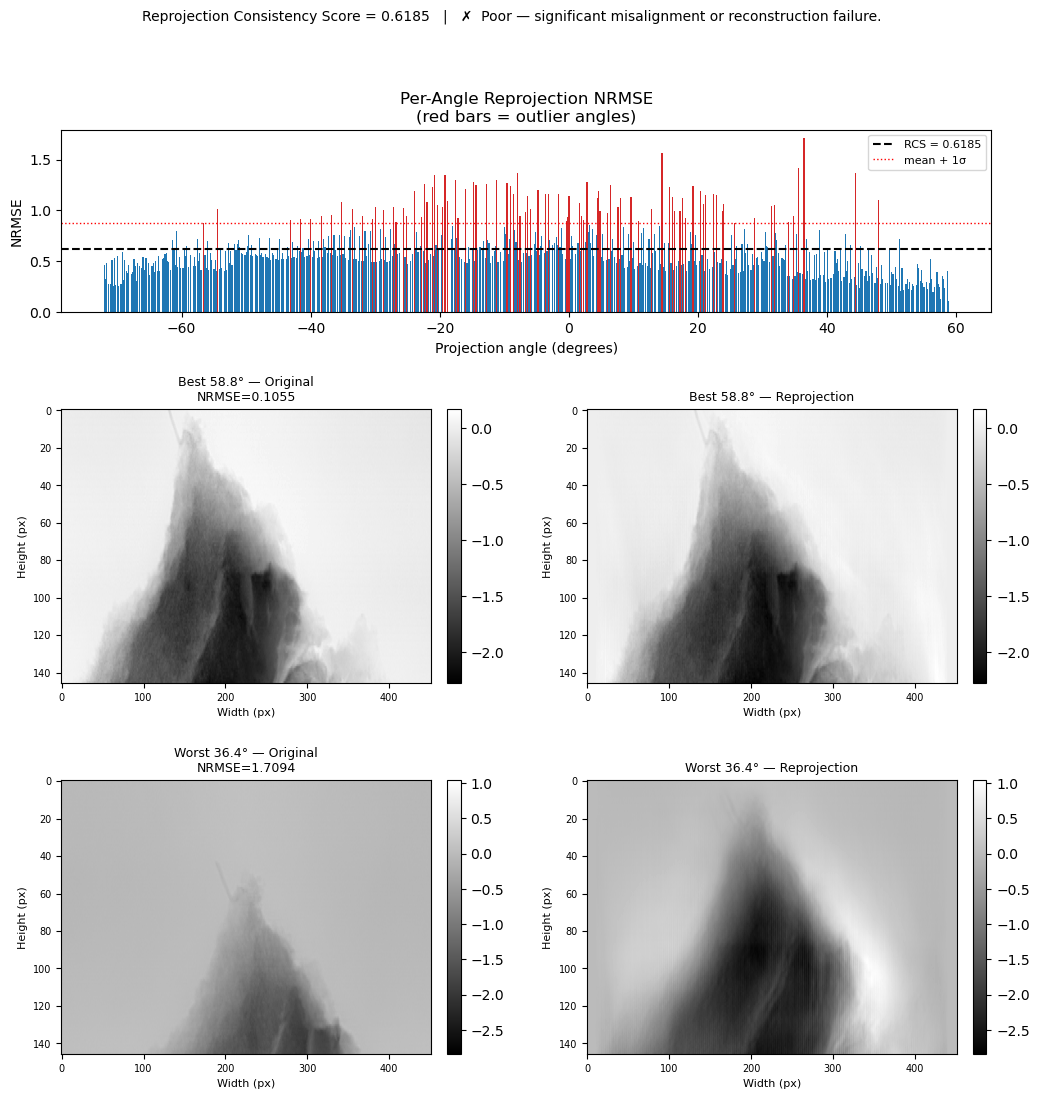



Sinogram consistency:
  x_cm (horizontal) — RMSE: 14.3736 px  |  R²: 0.257821
  y_cm (vertical)   — RMSE: 2.9024 px  |  R²: 0.000000
  Combined RMSE:       10.3688 px


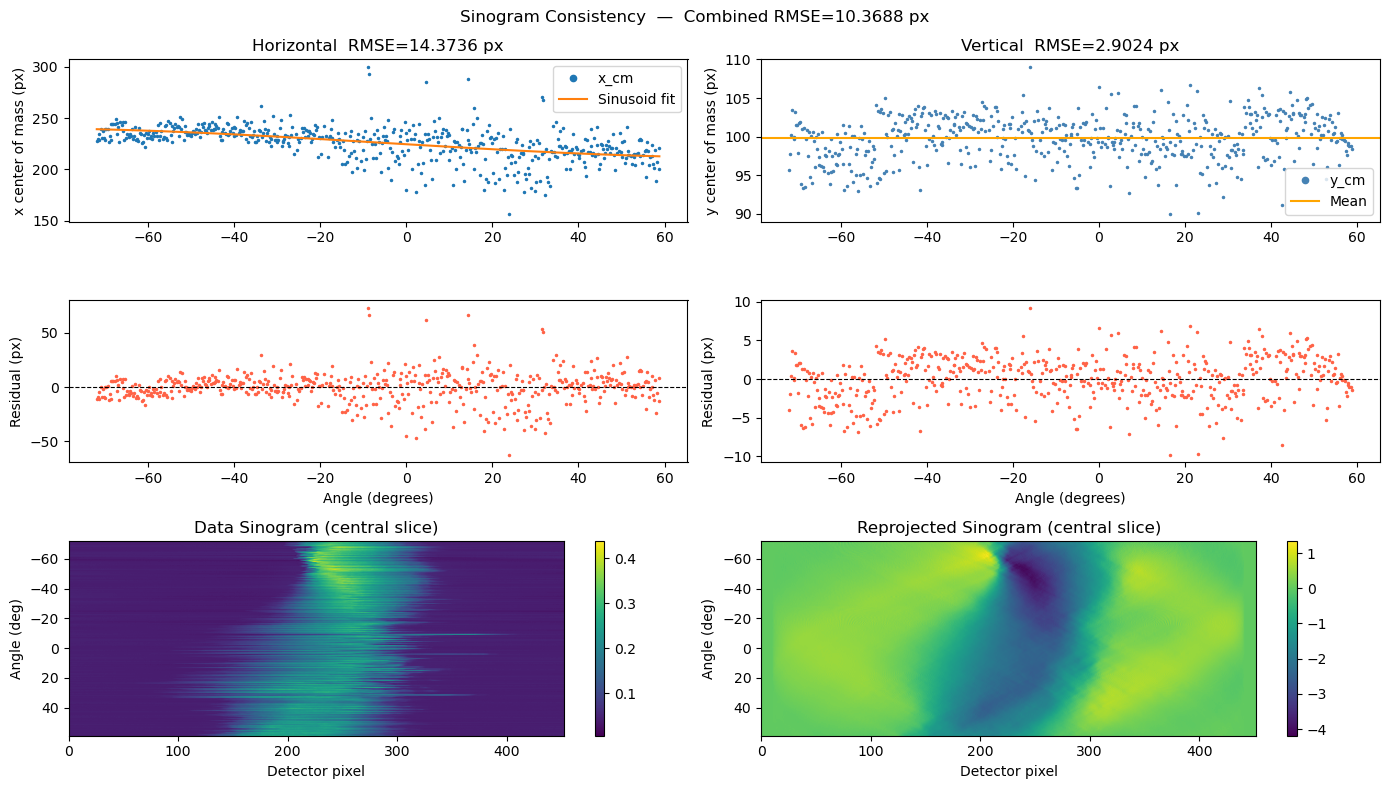

In [7]:
# Reprojection Consistency Score — before alignment
rcs_before, _, _ = tomo.reprojection_consistency_score(plot=True)

#Sinogram consistency score — before alignment
scs_before, _, _, _, _ = tomo.sinogram_consistency_score(plot=True)

In [ ]:
tomo.reset_workingProjections(x_size=projections.shape[2]-(500//downsample), y_size=projections.shape[1], )
tomo.normalize(isPhaseData=True)

#Best XC params from sweep:
# Coarse passes: stepRatio=0.9 (stable global convergence)
tomo.cross_correlate_align(tolerance=0, maxShiftTolerance=0, max_iterations=10, stepRatio=0.9, yROI_Range=None, xROI_Range=None, isFull360=False, downsample=4, use_grad=True)
tomo.cross_correlate_align(tolerance=0, maxShiftTolerance=0, max_iterations=10, stepRatio=0.9, yROI_Range=None, xROI_Range=None, isFull360=False, downsample=2, use_grad=True)
# Final pass: stepRatio=0.75-0.8 with more iterations (fine-scale sharpness)
tomo.cross_correlate_align(tolerance=0, maxShiftTolerance=0, max_iterations=5, stepRatio=0.8, yROI_Range=None, xROI_Range=None, isFull360=False, downsample=1, use_grad=True)

tomo.PMA(max_iterations=5, tolerance=0, algorithm='SIRT_CUDA', levels=3, scale=4, iterations_per_level=[5,5,2], shift_method='optical_flow', of_sigma=3.0, stepRatio=0.9, plot=True)
tomo.make_updates_shift()



Normalizing projections


Cross-Correlation Alignment  [4x downsample | full frame | gradient mode]


Iteration 1/10: 100%|██████████| 557/557 [00:06<00:00, 86.59it/s] 


Iteration 1: avg shift = 18.7830 px, max shift = 93.6389 px


Iteration 2/10: 100%|██████████| 557/557 [00:03<00:00, 169.87it/s]


Iteration 2: avg shift = 1.8486 px, max shift = 23.7409 px


...

Iteration 10/10: 100%|██████████| 557/557 [00:03<00:00, 173.47it/s]


Iteration 10: avg shift = 0.1325 px, max shift = 4.2175 px
Maximum iterations reached without convergence.


Cross-Correlation Alignment  [2x downsample | full frame | gradient mode]


Iteration 1/10: 100%|██████████| 557/557 [00:05<00:00, 96.58it/s] 


Iteration 1: avg shift = 0.3868 px, max shift = 8.9829 px


Iteration 2/10: 100%|██████████| 557/557 [00:04<00:00, 114.05it/s]


In [ ]:
tomo.makeNotebookProjMovie()
tomo.reconstruct(algorithm='art')
print("\nGood Reconstruction after alignment")
tomo.makeNotebookReconMovie()

In [ ]:
# Reprojection Consistency Score — after alignment
rcs_after, _, _ = tomo.reprojection_consistency_score(plot=True)

#Sinogram consistency score — after alignment
scs_after, _, _, _, _ = tomo.sinogram_consistency_score(plot=True)

# # print("=" * 52)
# # print("  ALIGNMENT QUALITY SUMMARY")
# # print("=" * 52)
# # print(f"  {'Metric':<22} {'Before':>8} {'After':>8} {'Δ':>10}")
# # print(f"  {'-'*50}")
# # print(f"  {'RCS (lower = better)':<22} {rcs_before:>8.4f} {rcs_after:>8.4f} {rcs_before - rcs_after:>+10.4f}")
# # print("=" * 52)

In [ ]:
import tifffile
tifffile.imwrite("reconstruction(downsampled).tiff", tomo.recon.astype("float32"))